# **STUDNET PERFORMANCE INDICATOR**





## Life cycle of Machine learning Project
- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.


## Importing Required packages for the EDA


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'numpy'

### Importing the dataset

In [257]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Projects/ML/KN_student-Performance \/Data/stud.csv')

READING 5 RECORDS OF THE DATA


In [258]:
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Basic EDA

In [259]:
df.shape

(1000, 8)

In [260]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [261]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


To check unique data

In [262]:
def get_unique_values(df):
    unique_data = {}

    for column in df.columns:
        unique_data[column] = df[column].unique().tolist()

    return unique_data

In [263]:
result = get_unique_values(df)
result

{'gender': ['female', 'male'],
 'race_ethnicity': ['group B', 'group C', 'group A', 'group D', 'group E'],
 'parental_level_of_education': ["bachelor's degree",
  'some college',
  "master's degree",
  "associate's degree",
  'high school',
  'some high school'],
 'lunch': ['standard', 'free/reduced'],
 'test_preparation_course': ['none', 'completed'],
 'math_score': [72,
  69,
  90,
  47,
  76,
  71,
  88,
  40,
  64,
  38,
  58,
  65,
  78,
  50,
  18,
  46,
  54,
  66,
  44,
  74,
  73,
  67,
  70,
  62,
  63,
  56,
  97,
  81,
  75,
  57,
  55,
  53,
  59,
  82,
  77,
  33,
  52,
  0,
  79,
  39,
  45,
  60,
  61,
  41,
  49,
  30,
  80,
  42,
  27,
  43,
  68,
  85,
  98,
  87,
  51,
  99,
  84,
  91,
  83,
  89,
  22,
  100,
  96,
  94,
  48,
  35,
  34,
  86,
  92,
  37,
  28,
  24,
  26,
  95,
  36,
  29,
  32,
  93,
  19,
  23,
  8],
 'reading_score': [72,
  90,
  95,
  57,
  78,
  83,
  43,
  64,
  60,
  54,
  52,
  81,
  53,
  75,
  89,
  32,
  42,
  58,
  69,
  73,
  71,
  

## 2.2 ABOUT THE DATA
Columns = 8
Named as -
1. gender: (MALE/Female)
2. race_ethnicity: (GROUP A,B,C,D,E)
3. parental_level_of_education: (Bachelor, Some clg, Master's, Associate's Degree, High school)
4. lunch-> before test :(standard or free / reduced)
5. test_preparation_course: (Complete or none)
6. maths_score
7. reading_score
8. writing_score

## 3. Data Checks To Perfrom
- Duplicates
- Null Values
- Data type of the columns
- Stats of the data
- Check various categories present in the different categorical columns

### 3.1. To check duplicates

In [264]:
df.duplicated().sum()

np.int64(0)

#### INSIGHT
- NO DUPLICACY IN DATA


### 3.2. TO CHECK NULL VALUES

In [265]:
df.isna().sum()

,0
gender,0
race_ethnicity,0
parental_level_of_education,0
lunch,0
test_preparation_course,0
math_score,0
reading_score,0
writing_score,0


#### INSIGHT
- There are 0 Null Value IN DATA


### 3.3. To Check the Data type of the columns

In [266]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


#### INSIGHT
- Categorical Data: Categorical data represents qualities, labels, or groups
  -  Columns:
    1. gender: (MALE/Female)
    2. race_ethnicity: (GROUP A,B,C,D,E)
    3. parental_level_of_education: (Bachelor, Some clg, Master's, Associate's Degree, High school)
    4. lunch-> before test :(standard or free / reduced)
test_preparation_course: (Complete or none)


- Numerical Data: Numerical data represents quantities and amounts that you can measure or count
  - Columns:
    1. maths_score
    2. reading_score
    3. writing_score



### 3.4. To check the Statistics of the data

In [267]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### INSIGHT
- Mean of all the numerical columns are very close to each other between 66 to 69
- Standard Deviation of all the numerical columns are also very close bwteen 14 to 15
- Minimun value of the columns max score is 0  where in reading and writing its is 17 and 10 consequetively
- Max value of all the numerical columns are 100



## MORE EDA

In [268]:
numerical_columns= [feature for feature in df.columns if df[feature].dtype!='O']
categorical_columns= [feature for feature in df.columns if df[feature].dtype=='O']

print(f"We have {len(numerical_columns)} numerical columns which are : ",numerical_columns)
print(f"We have {len(categorical_columns)} categorical columns which are : ",categorical_columns)

We have 3 numerical columns which are :  ['math_score', 'reading_score', 'writing_score']
We have 5 categorical columns which are :  ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


## Feature engineering and extraction

In [269]:
df["total_score"]=df['math_score']+df['reading_score']+df['writing_score']
df['average_score']=df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


### Getting insight for maths about student

In [270]:
full_marks_maths = (df['math_score'] == 100).sum()

full_marks_reading = (df['reading_score'] == 100).sum()

full_marks_writing = (df['writing_score'] == 100).sum()

print(f"Number of students with full marks in Maths: {full_marks_maths}")
print(f"Number of students with full marks in Reading: {full_marks_reading}")
print(f"Number of students with full marks in Writing: {full_marks_writing}")

Number of students with full marks in Maths: 7
Number of students with full marks in Reading: 17
Number of students with full marks in Writing: 14


In [271]:
less_20_marks_maths = (df['math_score'] <= 20).sum()

less_20_marks_reading = (df['reading_score'] <= 20).sum()

less_20_marks_writing = (df['writing_score'] <= 20).sum()

print(f"Number of students with less then 20 marks in Maths: {less_20_marks_maths}")
print(f"Number of students with less then 20 marks in Reading: {less_20_marks_reading}")
print(f"Number of students with less then 20 marks in Writing: {less_20_marks_writing}")

Number of students with less then 20 marks in Maths: 4
Number of students with less then 20 marks in Reading: 1
Number of students with less then 20 marks in Writing: 3


#### INSIGHT
- Student have performed worst in maths and best in reading



# 4. Exploring Data (Visualization)

In [272]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


4.1 Visualize average score distribution to make some conclusion.
- Histogram
- Kernel Distribution Function (KDE)

## WE ARE CHECKING THE RANGE OF THE OUTPUT VARIABLE

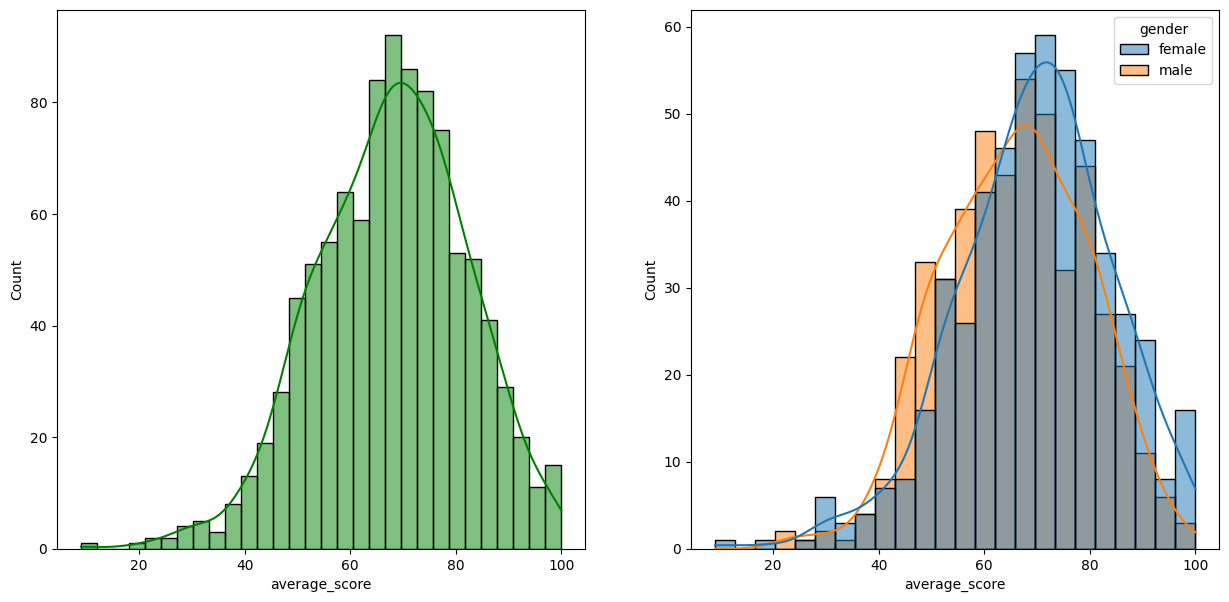

In [273]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average_score',kde=True,hue='gender')
plt.show()

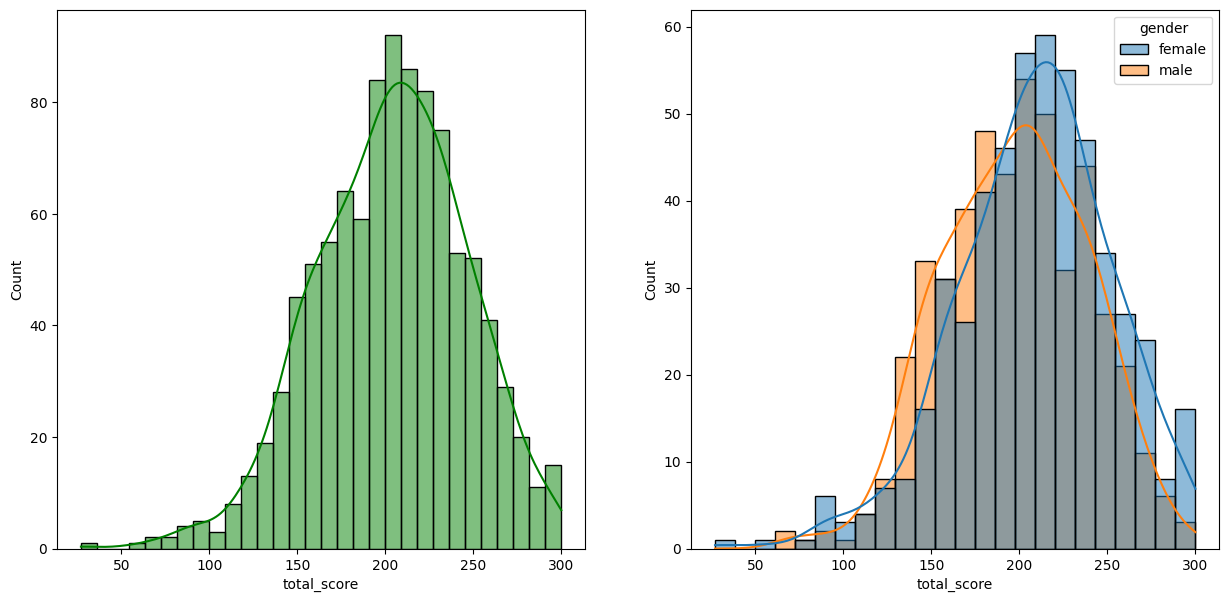

In [274]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')
plt.show()

#### INSIGHT
- As we can see female are good


## AVERAGE SCORE BASED ON LUNCH

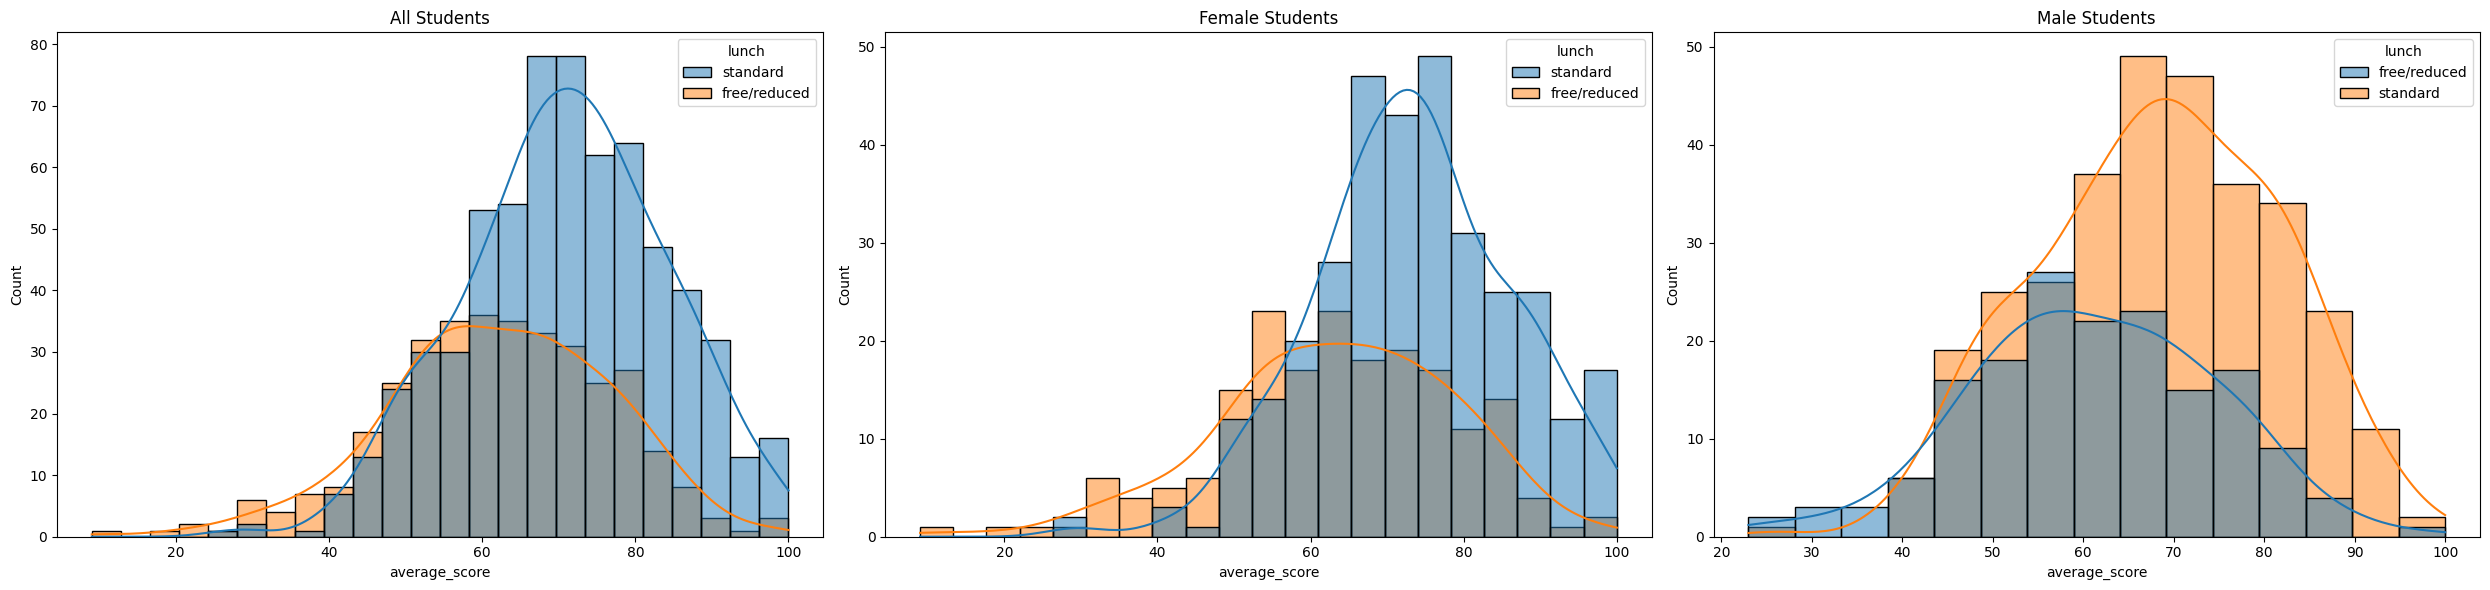

In [275]:
fig, axes = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data=df, x='average_score', kde=True, hue='lunch', ax=axes[0])
axes[0].set_title('All Students')

sns.histplot(
    data=df[df['gender'] == 'female'],
    x='average_score', kde=True, hue='lunch', ax=axes[1]
)
axes[1].set_title('Female Students')

sns.histplot(
    data=df[df['gender'] == 'male'],
    x='average_score', kde=True, hue='lunch', ax=axes[2]
)
axes[2].set_title('Male Students')

plt.tight_layout()
plt.show()

#### INSIGHT
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.


## AVERAGE SCORE BASED ON PARENTS EDUCATION

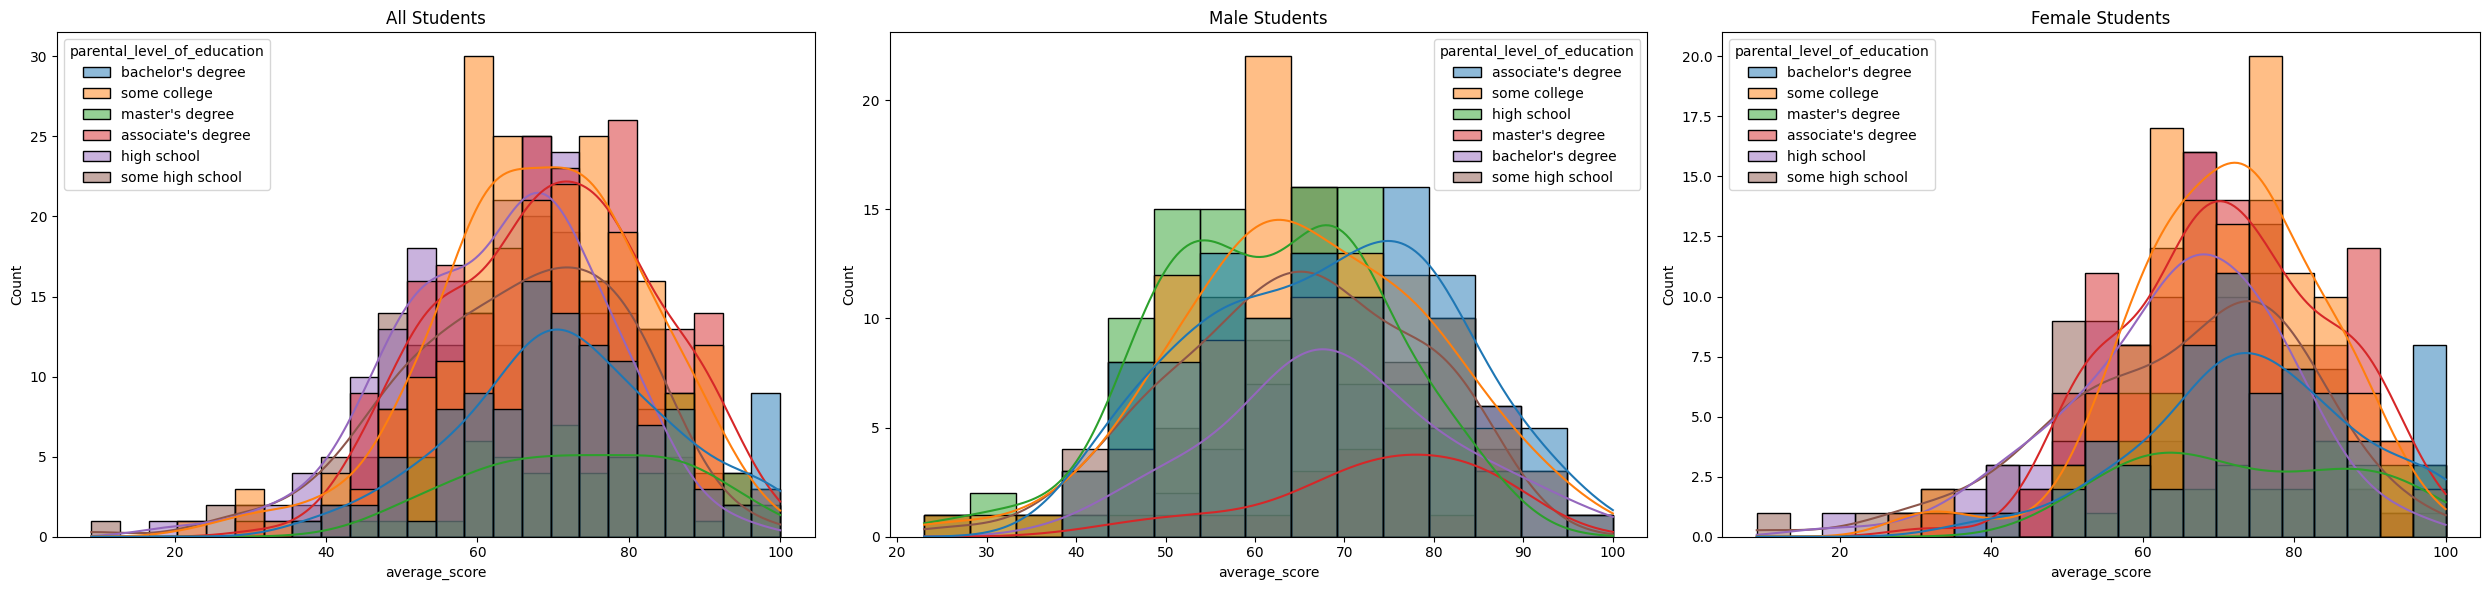

In [276]:
fig, axes = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(
    data=df,
    x='average_score',
    kde=True,
    hue='parental_level_of_education',
    ax=axes[0]
)
axes[0].set_title('All Students')

sns.histplot(
    data=df[df['gender'] == 'male'],
    x='average_score',
    kde=True,
    hue='parental_level_of_education',
    ax=axes[1]
)
axes[1].set_title('Male Students')

sns.histplot(
    data=df[df['gender'] == 'female'],
    x='average_score',
    kde=True,
    hue='parental_level_of_education',
    ax=axes[2]
)
axes[2].set_title('Female Students')

plt.tight_layout()
plt.show()

### Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students

# SCORE BASED ON THERE RACE/ETHNICITY


In [277]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'average_score'],
      dtype='object')

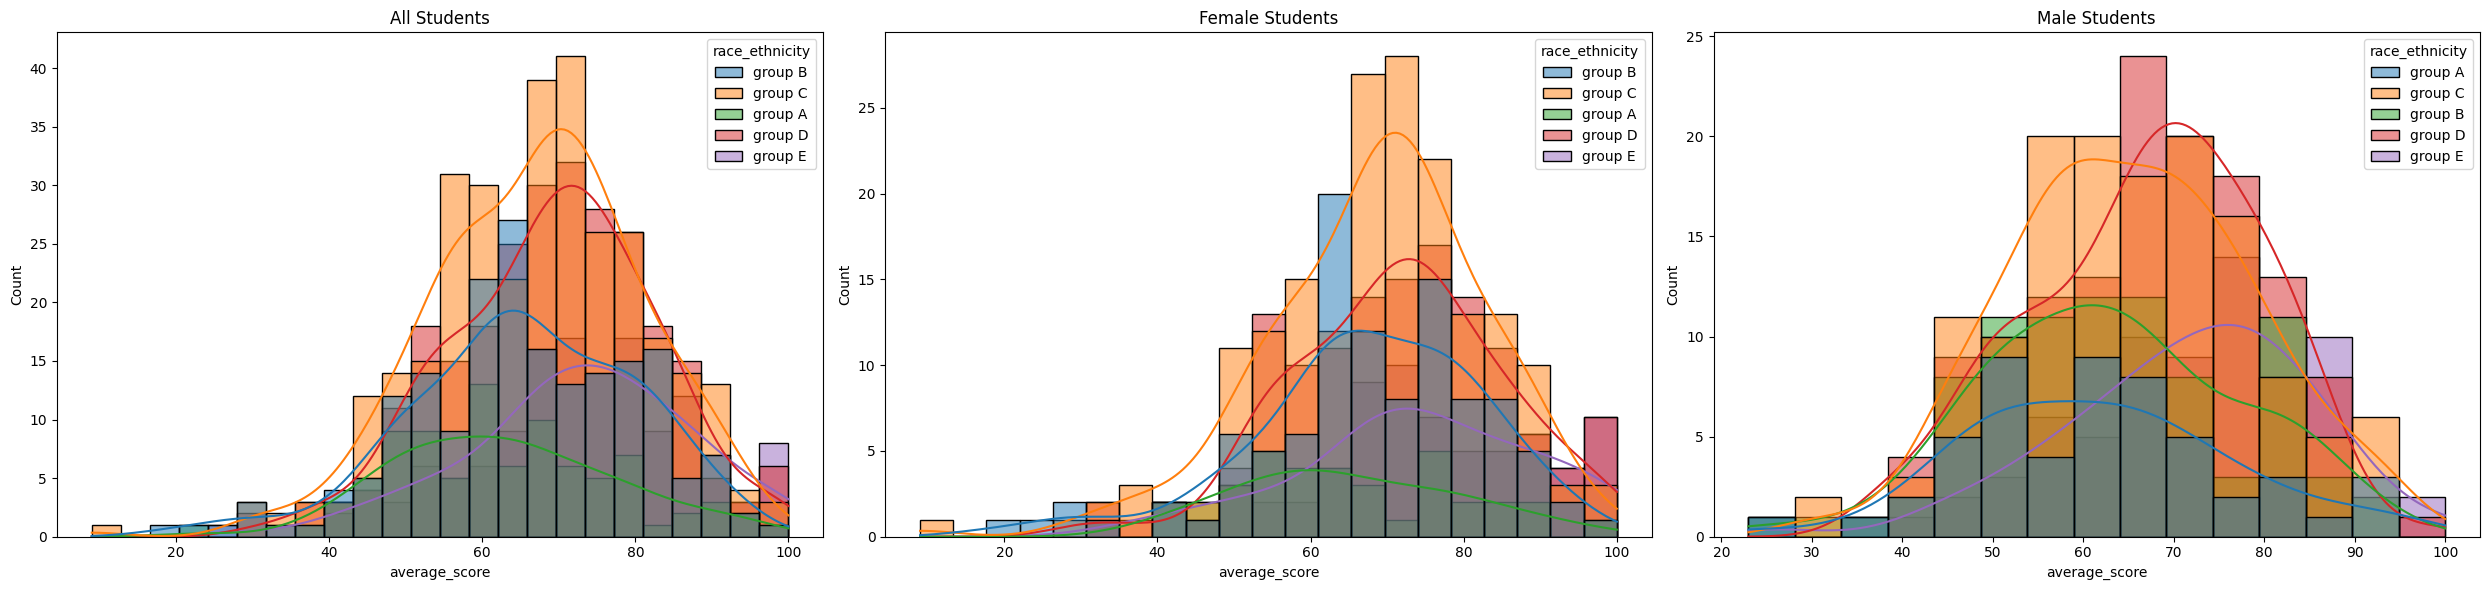

In [278]:
plt.figure(figsize=(25, 6))

plt.subplot(131)
sns.histplot(data=df, x='average_score', kde=True, hue='race_ethnicity')
plt.title('All Students')

plt.subplot(132)
sns.histplot(
    data=df[df['gender'] == 'female'],
    x='average_score', kde=True, hue='race_ethnicity'
)
plt.title('Female Students')

plt.subplot(133)
sns.histplot(
    data=df[df['gender'] == 'male'],
    x='average_score', kde=True, hue='race_ethnicity'
)
plt.title('Male Students')

plt.tight_layout()
plt.show()

###Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

# MAXIMUM SCORE OF STUDENTS IN THE 3 SUBJECTS

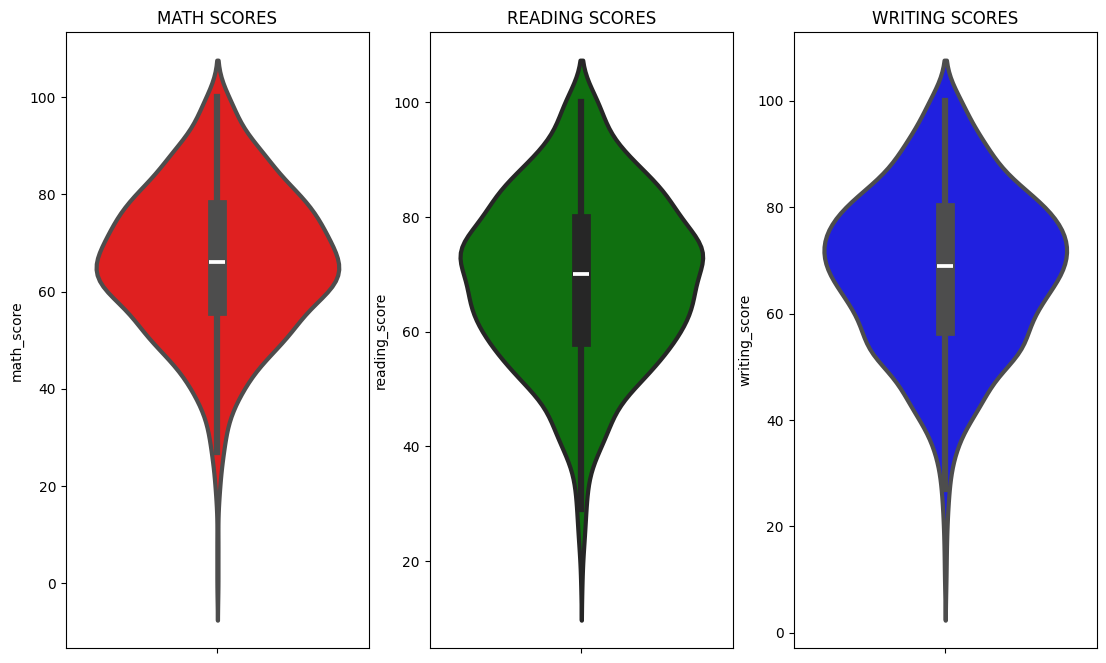

In [279]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80


## 4.3 Multivariate analysis using pieplot

In [280]:
df.columns


Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'average_score'],
      dtype='object')

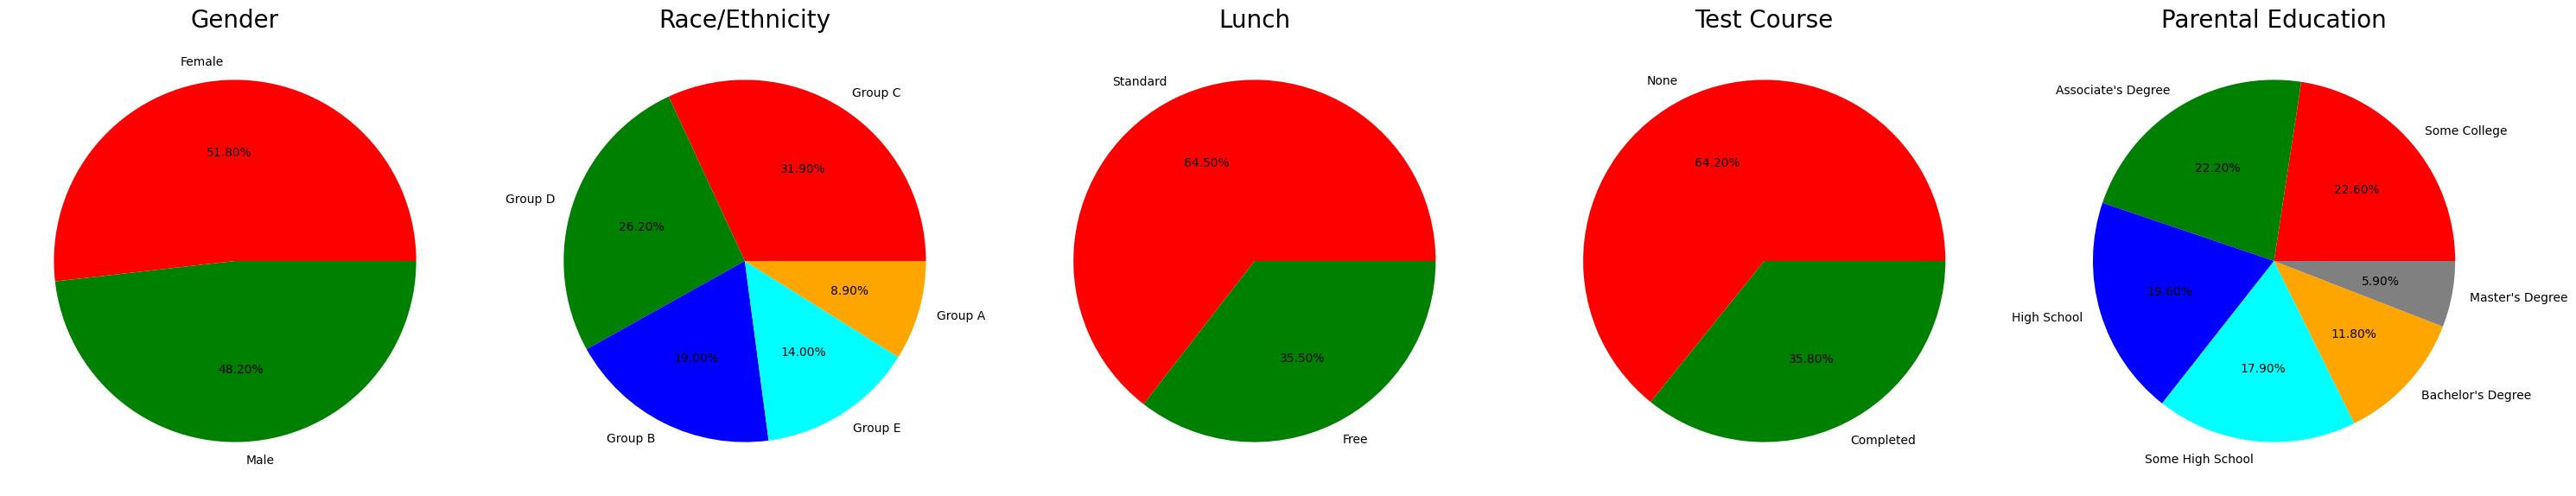

In [281]:
plt.rcParams['figure.figsize'] = (30, 12)

# 1. Gender
plt.subplot(1, 5, 1)

size = df['gender'].value_counts()
labels = ['Female', 'Male']
color = ['red', 'green']

plt.pie(
    size,
    colors=color,
    labels=labels,
    autopct='%.2f%%'
)

plt.title('Gender', fontsize=20)
plt.axis('off')


# 2. Race/Ethnicity
plt.subplot(1, 5, 2)

size = df['race_ethnicity'].value_counts()
labels = ['Group C', 'Group D', 'Group B', 'Group E', 'Group A']
color = ['red', 'green', 'blue', 'cyan', 'orange']

plt.pie(
    size,
    colors=color,
    labels=labels,
    autopct='%.2f%%'
)

plt.title('Race/Ethnicity', fontsize=20)
plt.axis('off')


# 3. Lunch
plt.subplot(1, 5, 3)

size = df['lunch'].value_counts()
labels = ['Standard', 'Free']
color = ['red', 'green']

plt.pie(
    size,
    colors=color,
    labels=labels,
    autopct='%.2f%%'
)

plt.title('Lunch', fontsize=20)
plt.axis('off')


# 4. Test Preparation Course
plt.subplot(1, 5, 4)

size = df['test_preparation_course'].value_counts()
labels = ['None', 'Completed']
color = ['red', 'green']

plt.pie(
    size,
    colors=color,
    labels=labels,
    autopct='%.2f%%'
)

plt.title('Test Course', fontsize=20)
plt.axis('off')


# 5. Parental Education
plt.subplot(1, 5, 5)

size = df['parental_level_of_education'].value_counts()
labels = [
    'Some College',
    "Associate's Degree",
    'High School',
    'Some High School',
    "Bachelor's Degree",
    "Master's Degree"
]

color = ['red', 'green', 'blue', 'cyan', 'orange', 'grey']

plt.pie(
    size,
    colors=color,
    labels=labels,
    autopct='%.2f%%'
)

plt.title('Parental Education', fontsize=20)
plt.axis('off')


plt.tight_layout()
plt.show()

### Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

##4.4 Feature Wise Visualization
###4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?
###UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

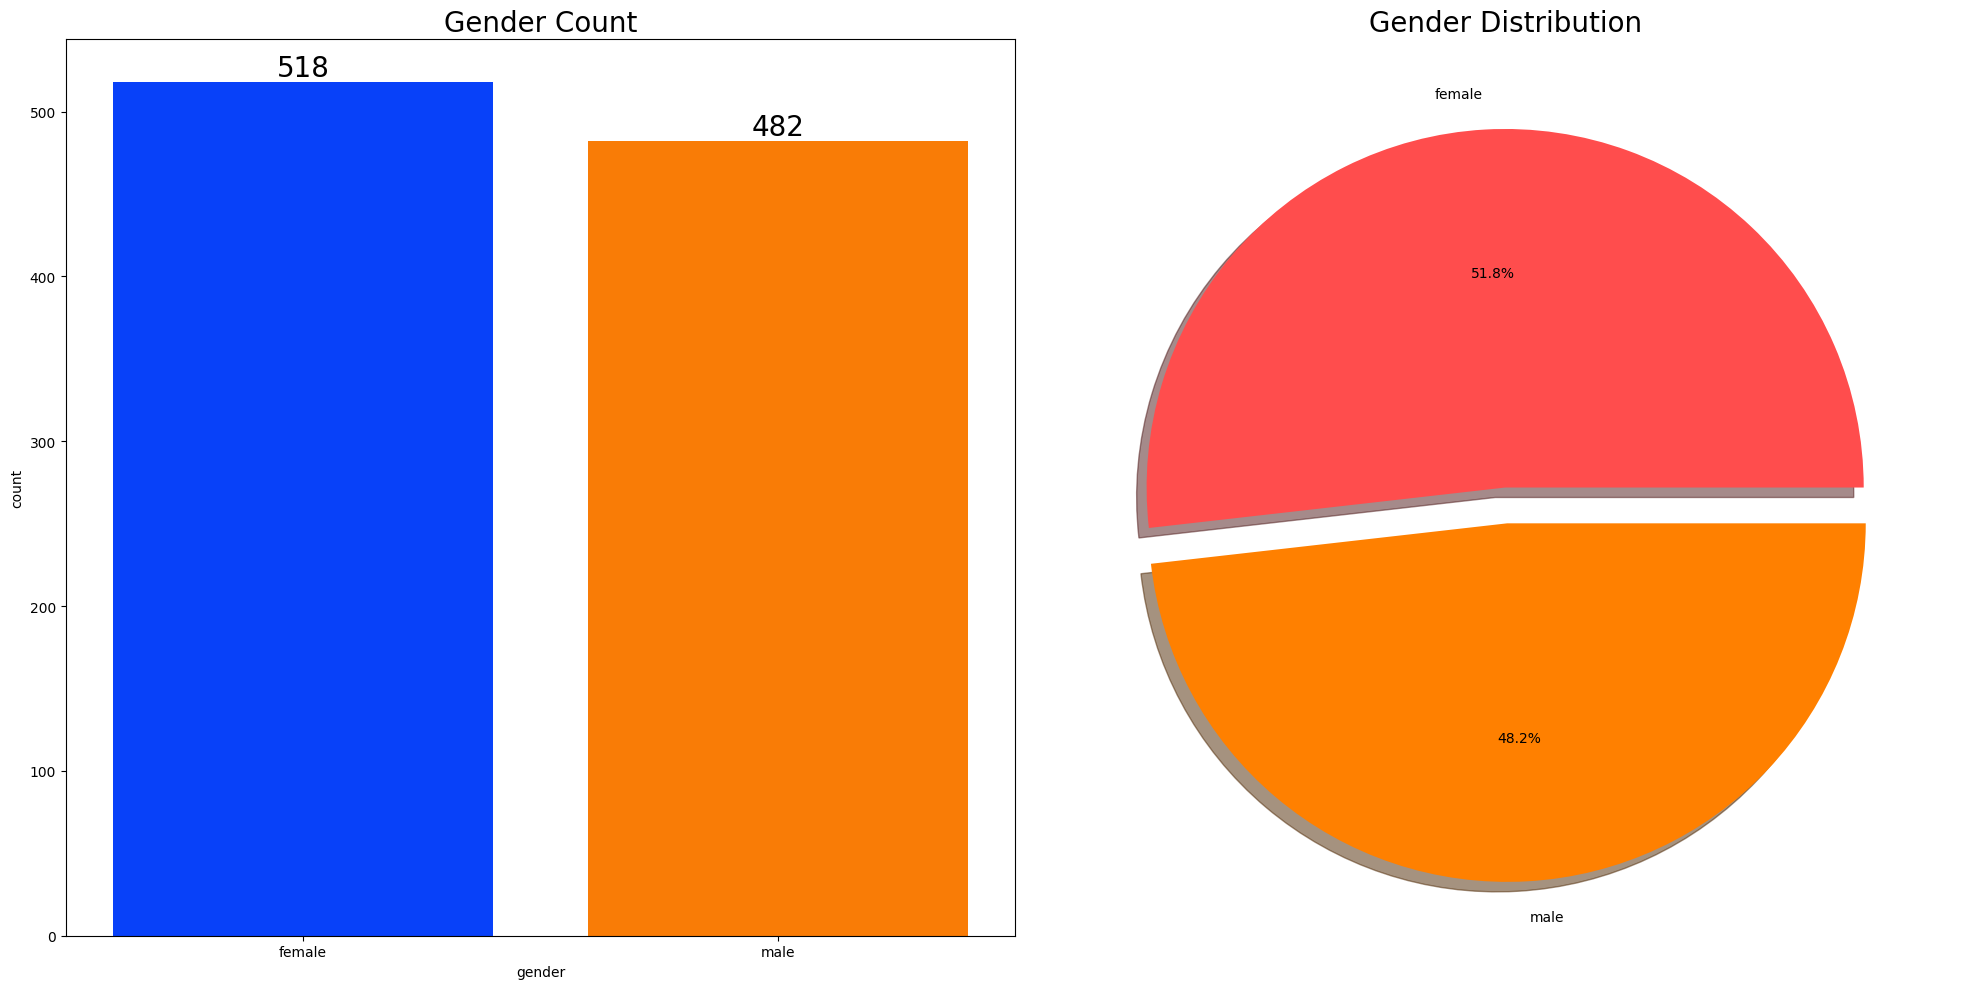

In [282]:
f, ax = plt.subplots(1, 2, figsize=(20, 10))

# Count plot
sns.countplot(
    x='gender',
    data=df,
    palette='bright',
    ax=ax[0],
    saturation=0.95,
    hue='gender',
    legend=False
)

# Add values on bars
for container in ax[0].containers:
    ax[0].bar_label(
        container,
        color='black',
        size=20
    )

ax[0].set_title('Gender Count', fontsize=20)


# Pie chart
gender_counts = df['gender'].value_counts()

ax[1].pie(
    gender_counts,
    labels=gender_counts.index,
    explode=[0, 0.1],
    autopct='%1.1f%%',
    shadow=True,
    colors=['#ff4d4d', '#ff8000']
)

ax[1].set_title('Gender Distribution', fontsize=20)


plt.tight_layout()
plt.show()

### Insights
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

## BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [283]:
gender_group = df.groupby('gender')[['average_score', 'math_score']].mean()

print(gender_group)

        average_score  math_score
gender                           
female      69.569498   63.633205
male        65.837483   68.728216


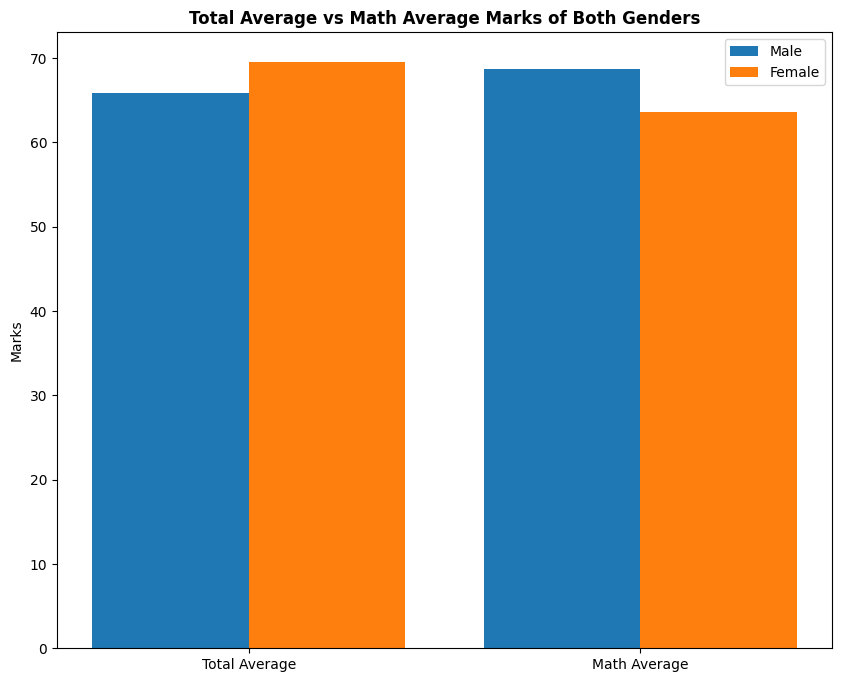

In [284]:
plt.figure(figsize=(10, 8))

X = ['Total Average', 'Math Average']

female_scores = [
    gender_group.loc['female', 'average_score'],
    gender_group.loc['female', 'math_score']
]

male_scores = [
    gender_group.loc['male', 'average_score'],
    gender_group.loc['male', 'math_score']
]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title(
    "Total Average vs Math Average Marks of Both Genders",
    fontweight='bold'
)

plt.legend()
plt.show()

### Insights
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

## UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

In [286]:
gender_group = df.groupby('gender')[['average_score', 'math_score']].mean()

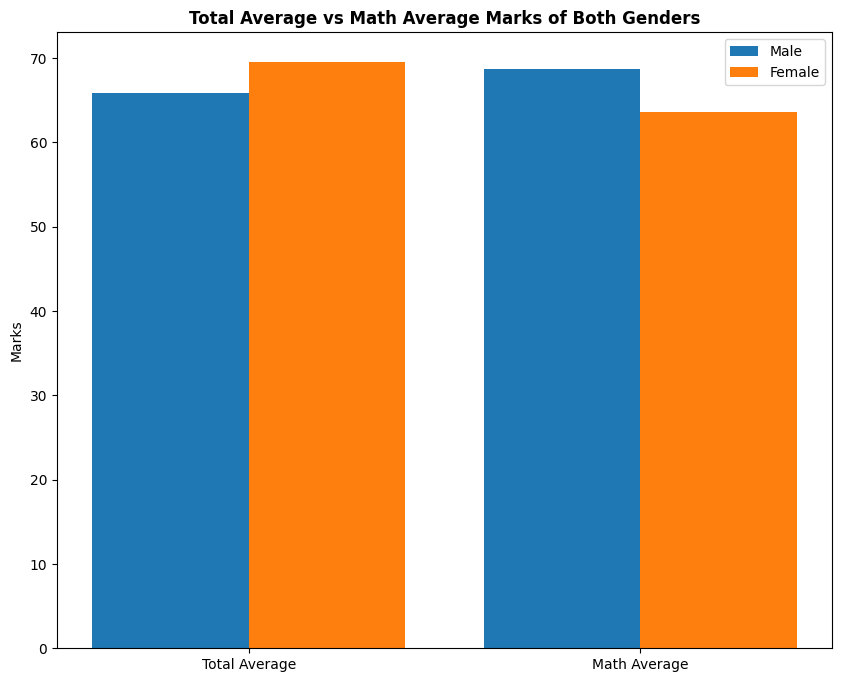

In [287]:
plt.figure(figsize=(10, 8))

X = ['Total Average', 'Math Average']

female_scores = [
    gender_group.loc['female', 'average_score'],
    gender_group.loc['female', 'math_score']
]

male_scores = [
    gender_group.loc['male', 'average_score'],
    gender_group.loc['male', 'math_score']
]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title(
    "Total Average vs Math Average Marks of Both Genders",
    fontweight='bold'
)
plt.legend()

plt.show()

###Insights
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.


##BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

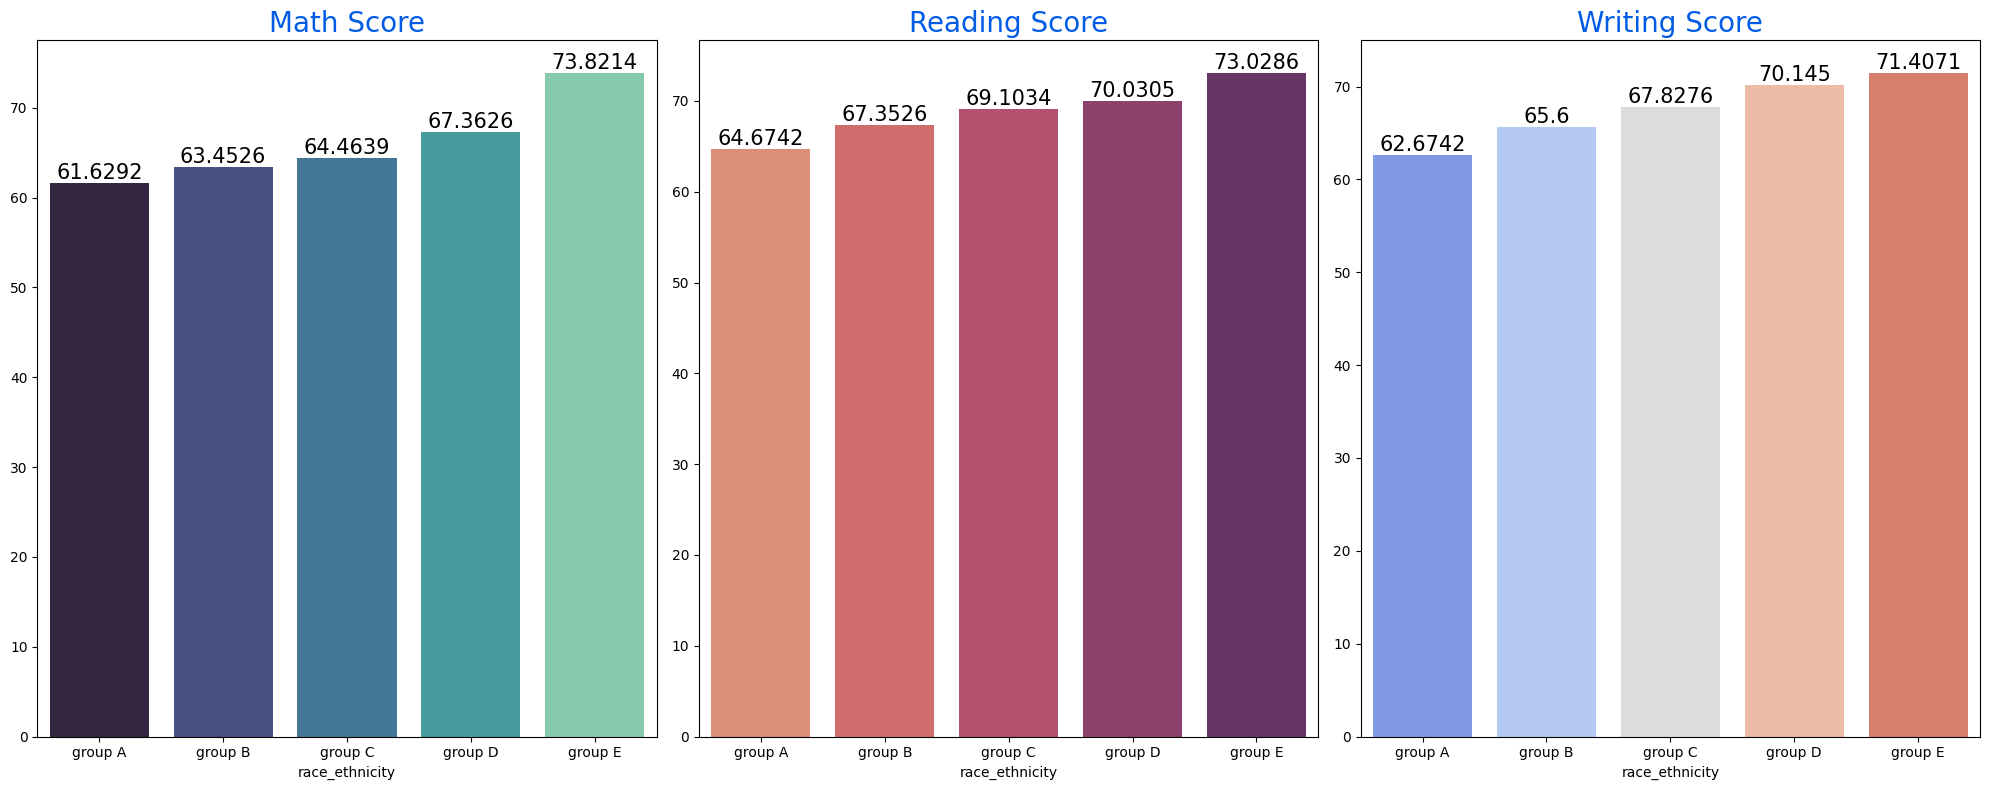

In [288]:
Group_data2 = df.groupby('race_ethnicity')

f, ax = plt.subplots(1, 3, figsize=(20, 8))

# Math Score
math_mean = Group_data2['math_score'].mean()

sns.barplot(
    x=math_mean.index,
    y=math_mean.values,
    palette='mako',
    ax=ax[0]
)

ax[0].set_title('Math Score', color='#005ce6', size=20)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)


# Reading Score
reading_mean = Group_data2['reading_score'].mean()

sns.barplot(
    x=reading_mean.index,
    y=reading_mean.values,
    palette='flare',
    ax=ax[1]
)

ax[1].set_title('Reading Score', color='#005ce6', size=20)

for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=15)


# Writing Score
writing_mean = Group_data2['writing_score'].mean()

sns.barplot(
    x=writing_mean.index,
    y=writing_mean.values,
    palette='coolwarm',
    ax=ax[2]
)

ax[2].set_title('Writing Score', color='#005ce6', size=20)

for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=15)

plt.tight_layout()
plt.show()

####Insights
- Group E students have scored the highest marks.
- Group A students have scored the lowest marks.

####Students from a lower Socioeconomic status have a lower avg in all course subjects


### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?
## UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

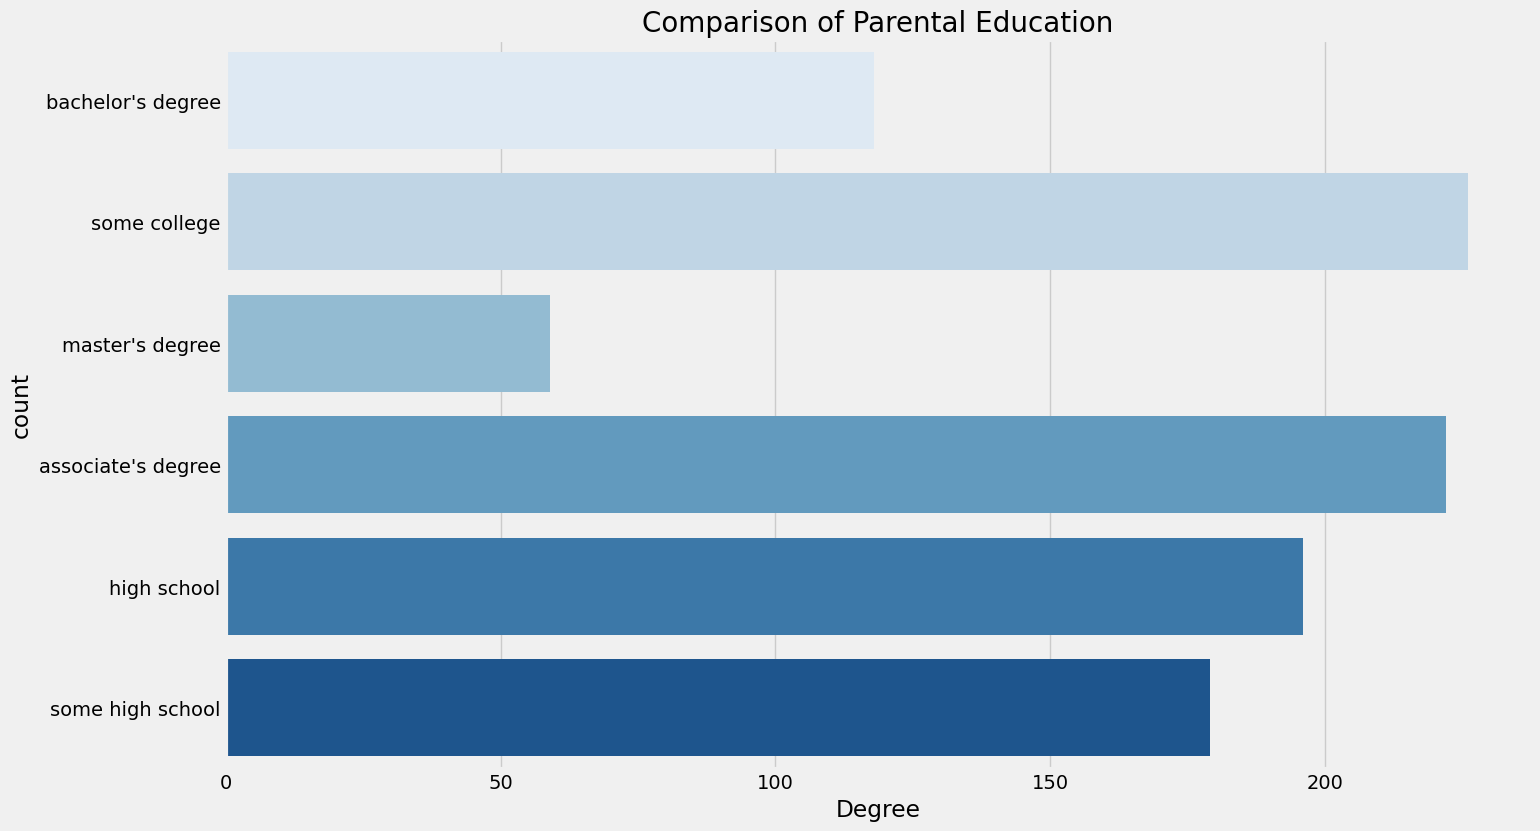

In [290]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

###Insights
- Largest number of parents are from some college.
##BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

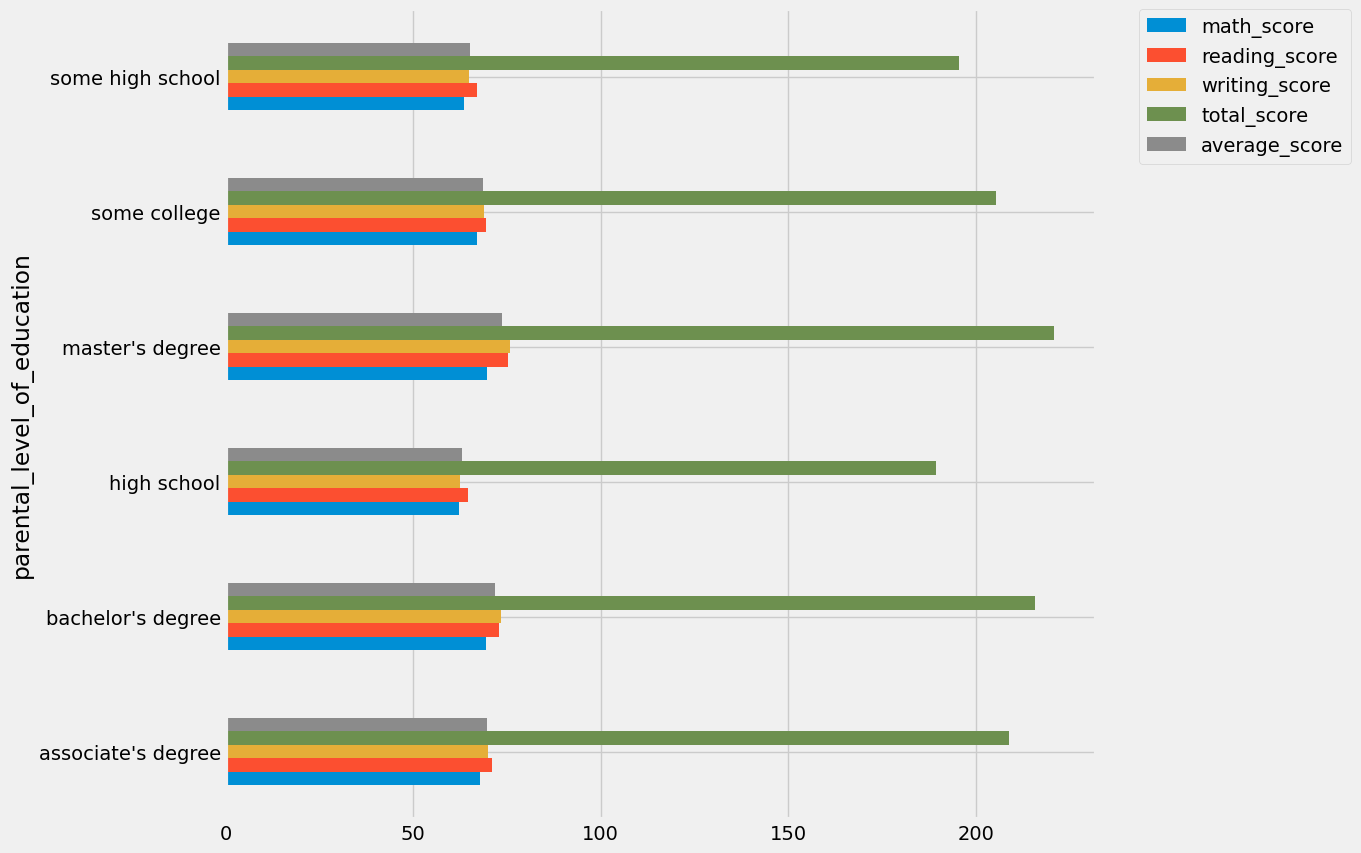

In [292]:
df.groupby('parental_level_of_education').mean(numeric_only=True).plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

###Insights
- The score of student whose parents possess master and bachelor level education are higher than others.

## 4.4.4 LUNCH COLUMN
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?

## UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

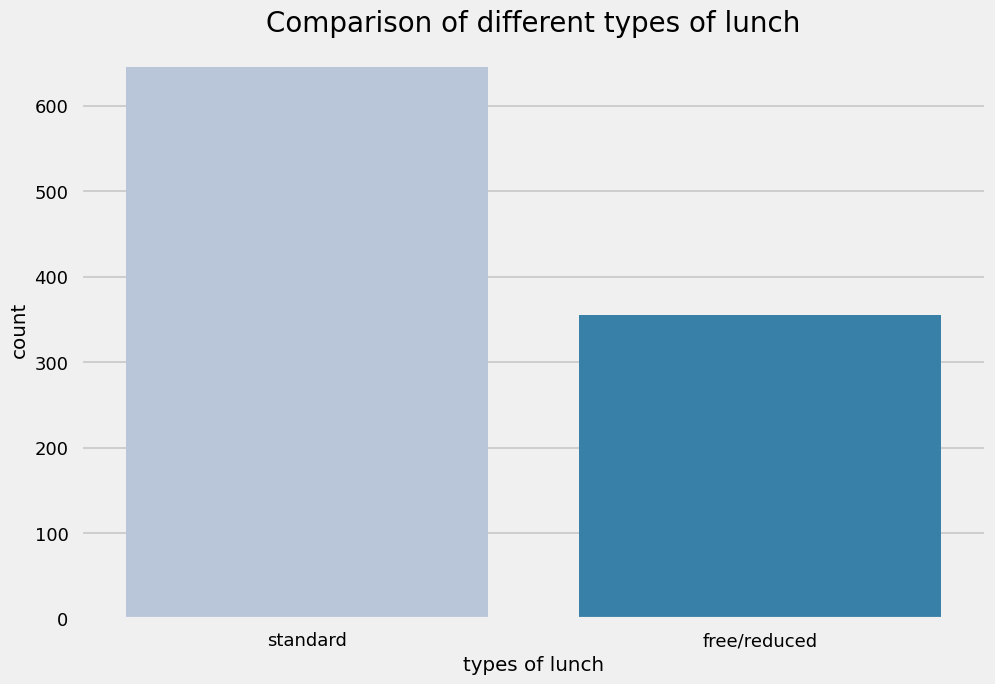

In [294]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(x=df['lunch'], palette='PuBu')
plt.title('Comparison of different types of lunch', fontweight=30, fontsize=20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

####Insights
- Students being served Standard lunch was more than free lunch


##BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

              math_score  reading_score  writing_score  average_score
lunch                                                                
free/reduced   58.921127      64.653521      63.022535      62.199061
standard       70.034109      71.654264      70.823256      70.837209


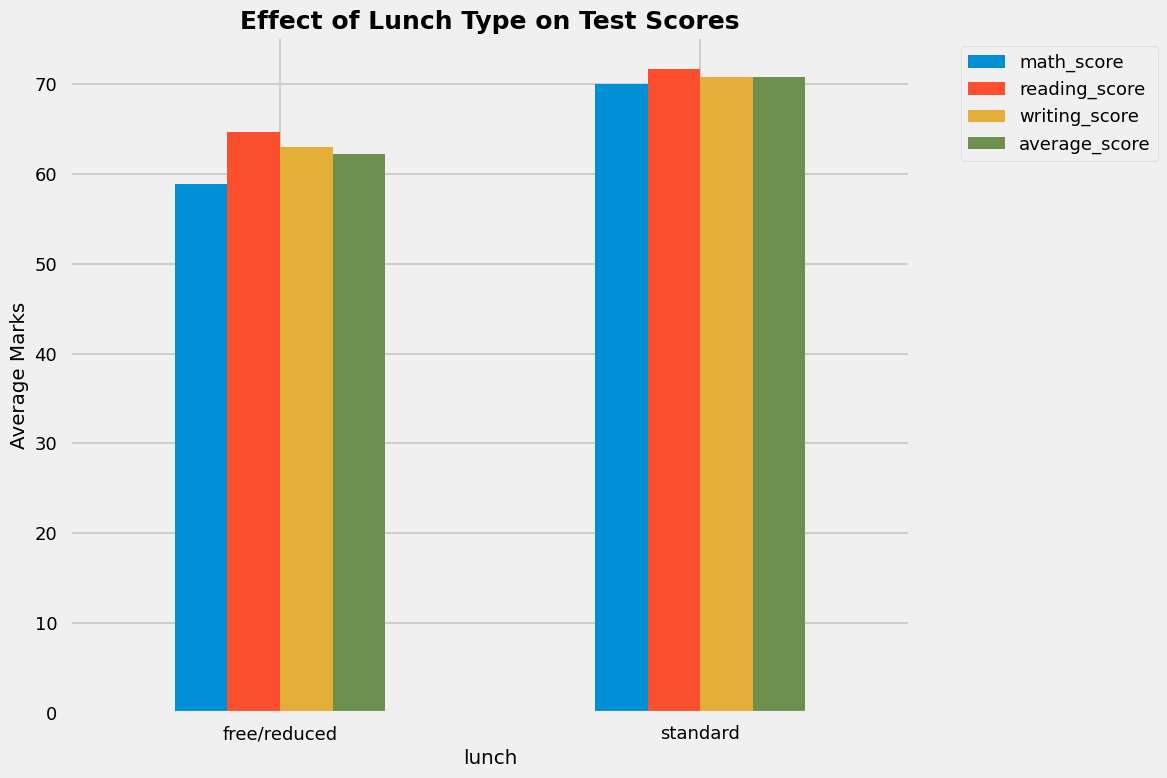

In [296]:
lunch_group = df.groupby('lunch')[['math_score', 'reading_score', 'writing_score', 'average_score']].mean(numeric_only=True)
print(lunch_group)

lunch_group.plot(kind='bar', figsize=(12, 8))
plt.title('Effect of Lunch Type on Test Scores', fontsize=18, fontweight='bold')
plt.ylabel('Average Marks')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Insights
- Students who have a **Standard Lunch** perform significantly better in exams (higher math, reading, and writing scores) compared to students who receive free or reduced lunch.
- This trend holds true across all test subjects, showing that proper nutrition or socioeconomic factors associated with lunch plans have a strong positive correlation with academic performance.

## 4.4.5 TEST PREPARATION COURSE COLUMN
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?
##BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='writing_score'>

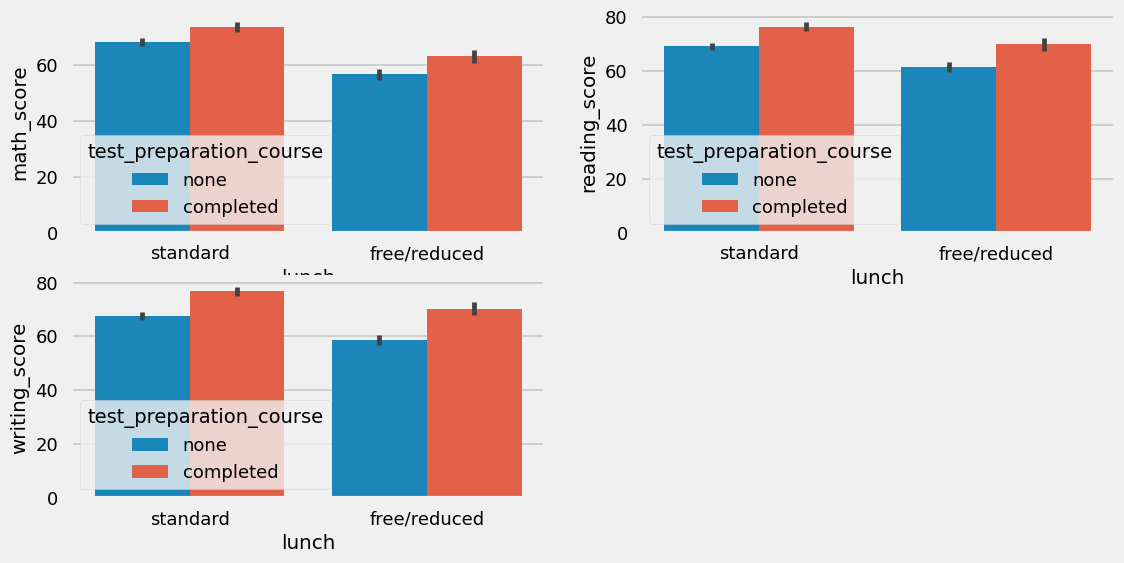

In [299]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])

####Insights
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course
##4.4.6 CHECKING OUTLIERS

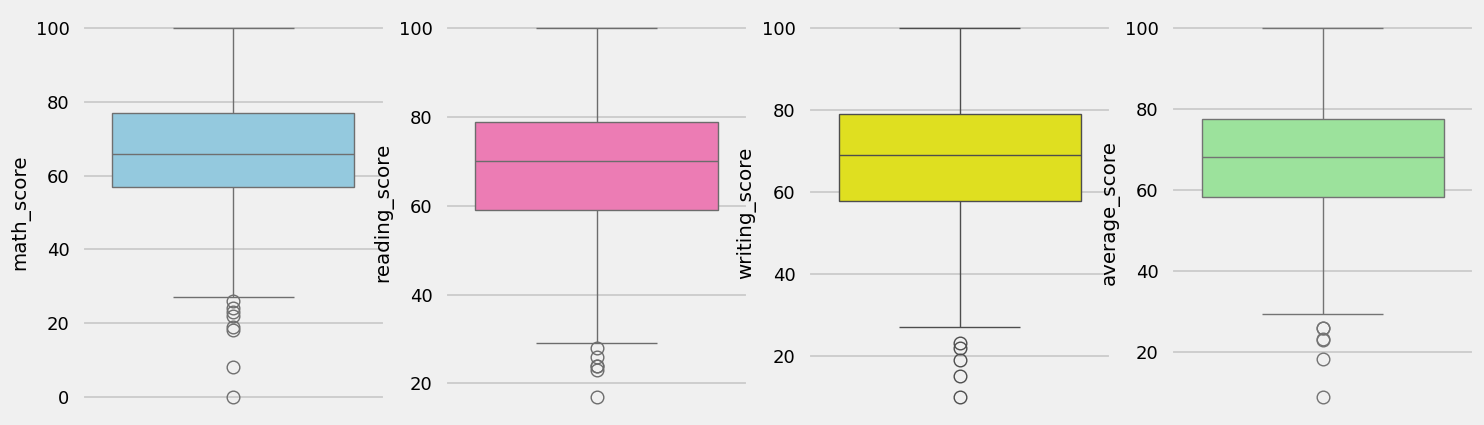

In [301]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average_score'],color='lightgreen')
plt.show()

## 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

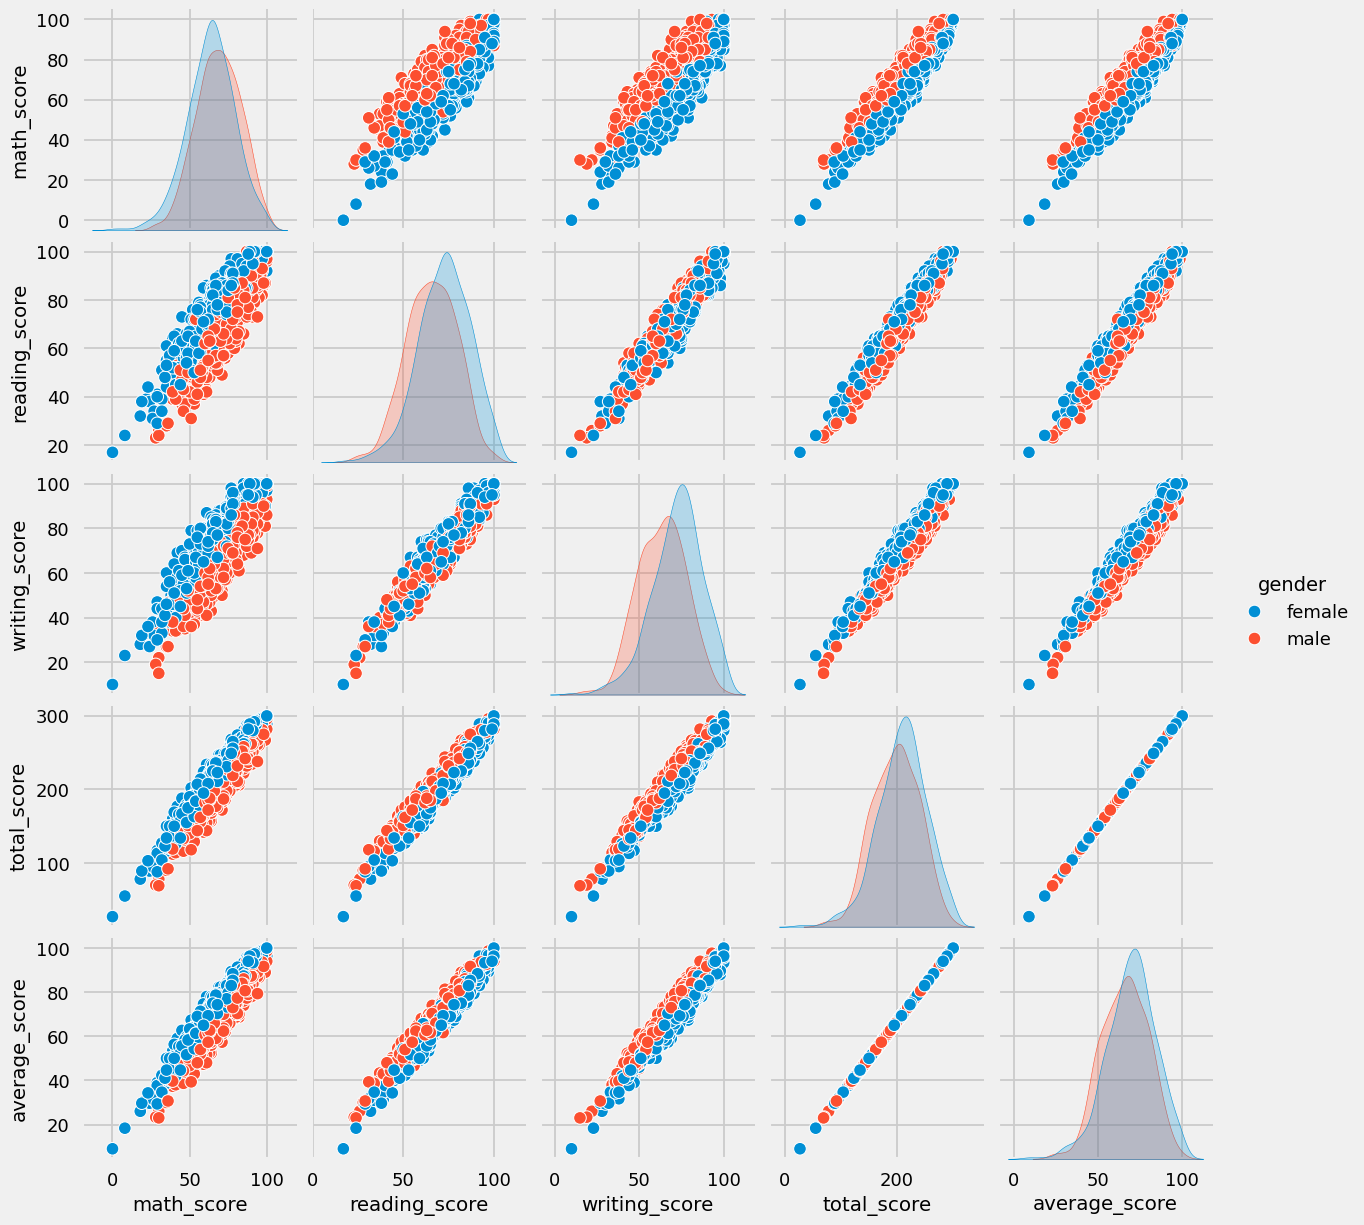

In [302]:
sns.pairplot(df,hue = 'gender')
plt.show()

## Insights
- From the above plot it is clear that all the scores increase linearly with each other.

## 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.